# Environment Setup

In [1]:
# Install required libraries
!pip install nltk spacy wordcloud matplotlib pandas
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 67.0 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
# Cell 2: Import dependencies and download NLTK data
import string
from collections import Counter
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import gutenberg, stopwords
from nltk.tokenize import word_tokenize
import pandas as pd
import spacy
from spacy import displacy
from wordcloud import WordCloud

# Download necessary NLTK datasets
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("gutenberg")
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")
nltk.download("maxent_ne_chunker")
nltk.download("maxent_ne_chunker_tab")
nltk.download("words")

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package gutenberg to /usr/share/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already u

True

# Task 1: Word Count, Top 10 Frequencies, and Word Cloud

### Raw Text → Tokenization → Lowercasing → Remove Punctuation → Remove Stopwords → Frequency Counting → Top 10 Words

## Load Document / Text Corpus

In [3]:
# Load sample text (Using Shakespeare's Macbeth from NLTK Gutenberg corpus or custom text)

raw_text = gutenberg.raw("shakespeare-macbeth.txt")

print(f"Sample preview (First 250 characters):\n{'-'*40}")
print(raw_text[:250])

Sample preview (First 250 characters):
----------------------------------------
[The Tragedie of Macbeth by William Shakespeare 1603]


Actus Primus. Scoena Prima.

Thunder and Lightning. Enter three Witches.

  1. When shall we three meet againe?
In Thunder, Lightning, or in Raine?
  2. When the Hurley-burley's done,
When the B


## Text Preprocessing & Frequency Distribution

In [4]:
# Tokenization, cleaning, and frequency counting
# 1. Tokenize into words
tokens = word_tokenize(raw_text)

# 2. Convert to lowercase & filter out punctuation and stopwords
stop_words = set(stopwords.words("english"))

cleaned_words = [
    word.lower()
    for word in tokens
    if word.isalpha() and word.lower() not in stop_words
]

# 3. Calculate word counts
total_raw_tokens = len(tokens)
total_cleaned_words = len(cleaned_words)
unique_words = len(set(cleaned_words))

print(f"Total Raw Tokens: {total_raw_tokens}")
print(
    f"Total Cleaned Words (excluding stopwords & punctuation): {total_cleaned_words}"
)
print(f"Unique Vocabulary Count: {unique_words}")

# 4. Extract Top 10 frequent words
word_freq = Counter(cleaned_words)
top_10 = word_freq.most_common(10)

# Display as DataFrame
df_top10 = pd.DataFrame(top_10, columns=["Word", "Frequency"])
print("\n--- Top 10 Most Frequent Words ---")
print(df_top10.to_string(index=False))

Total Raw Tokens: 22274
Total Cleaned Words (excluding stopwords & punctuation): 9640
Unique Vocabulary Count: 3225

--- Top 10 Most Frequent Words ---
   Word  Frequency
   macb        137
   haue        122
   thou         87
  enter         81
  shall         68
macbeth         62
   thee         61
   vpon         60
   macd         58
    yet         57


## Visualizations (Bar Chart & Word Cloud)

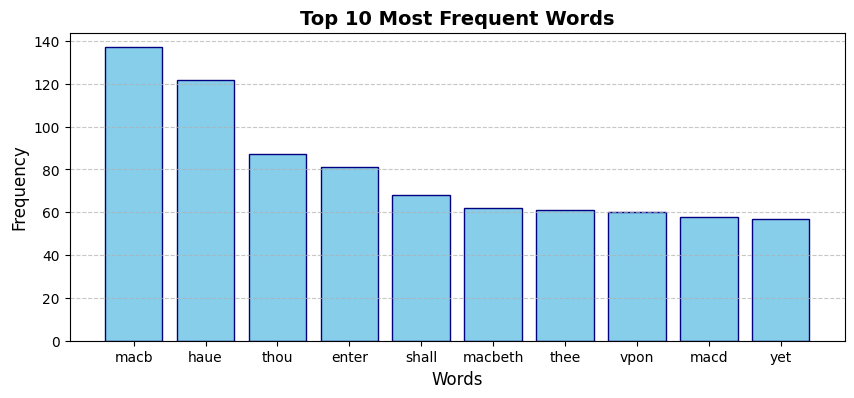

In [5]:
# Plot Top 10 Word Frequencies
plt.figure(figsize=(10, 4))
plt.bar(df_top10["Word"], df_top10["Frequency"], color="skyblue", edgecolor="navy")
plt.title("Top 10 Most Frequent Words", fontsize=14, fontweight="bold")
plt.xlabel("Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

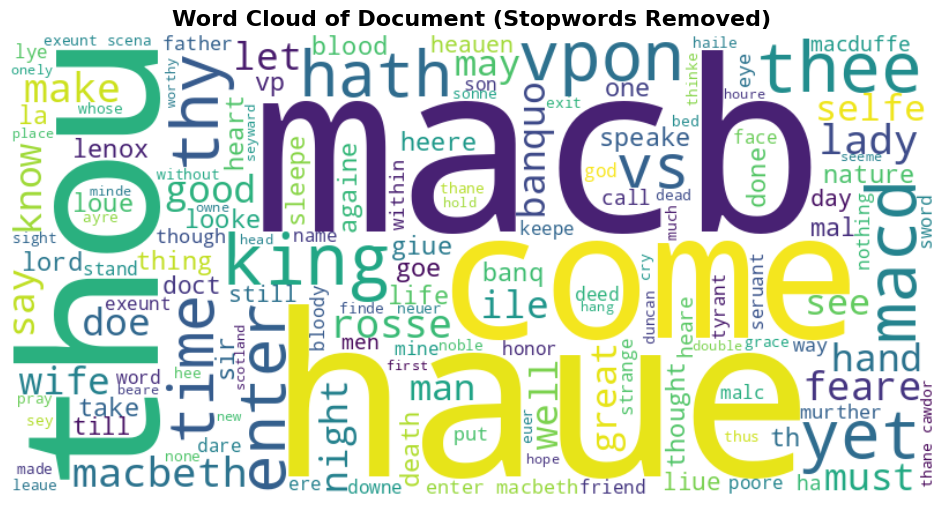

In [6]:
# Generate and Display Word Cloud
text_for_cloud = " ".join(cleaned_words)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="viridis",
    max_words=150,
).generate(text_for_cloud)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title(
    "Word Cloud of Document (Stopwords Removed)", fontsize=16, fontweight="bold"
)
plt.show()

# Task 2: Study & Implementation of Named Entity Recognition

### NER Theory Overview

**Named Entity Recognition (NER)** is an Information Extraction task that identifies named entities in unstructured text and classifies them into predefined categories (e.g., `PERSON`, `ORG` (Organization), `GPE` (Geopolitical Entity/Location), `DATE`, `MONEY`, `PERCENT`).

## Implementation using spaCy

In [7]:
# spaCy NER Implementation
nlp = spacy.load("en_core_web_sm")

sample_ner_text = """
Apple Inc. is planning to open a new campus in Austin, Texas by October 2025. 
Tim Cook announced an investment of $1 billion during the conference in New York.
Google and Microsoft are also expanding their AI research divisions across Europe.
"""

# Process the text
doc = nlp(sample_ner_text)

# Extract and display entities
entities_data = [
    (ent.text, ent.label_, spacy.explain(ent.label_)) for ent in doc.ents
]
df_entities = pd.DataFrame(
    entities_data, columns=["Entity Text", "Label", "Description"]
)

print("--- Extracted Named Entities (spaCy) ---")
print(df_entities.to_string(index=False))

--- Extracted Named Entities (spaCy) ---
 Entity Text  Label                                         Description
  Apple Inc.    ORG             Companies, agencies, institutions, etc.
      Austin    GPE                           Countries, cities, states
       Texas    GPE                           Countries, cities, states
October 2025   DATE               Absolute or relative dates or periods
    Tim Cook PERSON                         People, including fictional
  $1 billion  MONEY                     Monetary values, including unit
    New York    GPE                           Countries, cities, states
      Google    ORG             Companies, agencies, institutions, etc.
   Microsoft    ORG             Companies, agencies, institutions, etc.
          AI    GPE                           Countries, cities, states
      Europe    LOC Non-GPE locations, mountain ranges, bodies of water


In [8]:
# Visualizing Entities with spaCy DisplaCy
displacy.render(doc, style="ent", jupyter=True)

## Implementation using NLTK (ne_chunk)

In [9]:
# NLTK NER Implementation
nltk_tokens = word_tokenize(sample_ner_text)
pos_tags = nltk.pos_tag(nltk_tokens)
ner_tree = nltk.ne_chunk(pos_tags)

# Extract named entities from tree
nltk_entities = []
for subtree in ner_tree:
    if hasattr(subtree, "label"):
        entity_name = " ".join(c[0] for c in subtree)
        entity_type = subtree.label()
        nltk_entities.append((entity_name, entity_type))

df_nltk_ner = pd.DataFrame(
    nltk_entities, columns=["Entity Text", "Entity Type"]
)
print("--- Extracted Named Entities (NLTK) ---")
print(df_nltk_ner.to_string(index=False))

--- Extracted Named Entities (NLTK) ---
Entity Text  Entity Type
      Apple       PERSON
       Inc. ORGANIZATION
     Austin          GPE
      Texas          GPE
   Tim Cook       PERSON
   New York          GPE
     Google       PERSON
  Microsoft ORGANIZATION
     Europe          GPE


| Metric / Aspect | NLTK NER (`ne_chunk`) | spaCy NER (`en_core_web_sm`) |
| :--- | :--- | :--- |
| **Model Type** | Rule-based / Statistical Classifier | Transition-based Convolutional/Transformer NLP Pipeline |
| **Entity Types** | Basic (`PERSON`, `ORGANIZATION`, `GPE`, `LOCATION`, `FACILITY`) | Detailed (`PERSON`, `ORG`, `GPE`, `DATE`, `MONEY`, `PERCENT`, `EVENT`, etc.) |
| **Speed & Accuracy**| Moderate accuracy, slower on long documents | Fast, high precision and recall on real-world text |
| **Visualization** | Text tree representation | Built-in HTML visualizer (`displacy`) |

### Lab Exercises

1. **Custom Corpus Ingestion:**
   Load a `.txt` file of your choice (e.g., a news article or an essay). Compute the type-token ratio (TTR = $\frac{\text{Unique Words}}{\text{Total Words}}$) and display the top 15 words.

2. **Domain-Specific Stopword Filtering:**
   Extend the default NLTK stopword list by adding custom domain words (e.g., `"said"`, `"would"`, `"could"`, `"mr"`) and re-generate the Word Cloud. Observe how the top terms change.

3. **NER Entity Frequency Analysis:**
   Run spaCy NER on a larger text (e.g., 5 paragraphs of a news feed). Group and count all extracted entities by their label (e.g., total count of `GPE`, `ORG`, and `PERSON`) and plot a horizontal bar chart showing entity distribution.

